## Reproducibility : Set Random Seeds

We set a seed (42) so that every time this notebook runs, everyone on the team gets the exact same results no matter whose computer it's on. Without this, the notebook would shuffle images differently each time it runs, making it impossible to compare results fairly across the team.

In [12]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


# Sprint 2 Preprocessing Pipeline
### Dog Breed Classification

My task: Take the cleaned dog images and prepare them so the AI model can learn from them.

This means:

Resizing all images to the same size, adjusting image colors to a standard range the model expects, flipping/rotating some images to help the model learn better, Loading images in groups (batches) instead of one by one

Our teammate already cleaned the data and removed any bad or mislabeled images. The final list of good images was saved to dogs_updated.csv, which has 3 columns:

filepaths: where each image is stored

labels: what dog breed it is

data set: whether the image is used for training, validating, or testing

## Imports

In [13]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

## 1. Load the Cleaned Dataset CSV

`dogs_updated.csv` was produced by the EDA/cleaning notebook. It already excludes the Coyote
folder and the mislabeled images that were manually identified, so we can trust every row here
is a correctly labeled, valid image.

In [3]:
CSV_PATH = "../data/dogs_updated.csv"
IMAGE_ROOT = "../data"

df = pd.read_csv(CSV_PATH)

print(f"Total images: {len(df)}")
print(df["data set"].value_counts())
df.head()

Total images: 8694
data set
train    7325
valid     687
test      682
Name: count, dtype: int64


,filepaths,labels,data set
0,train/Afghan/001.jpg,Afghan,train
1,train/Afghan/002.jpg,Afghan,train
2,train/Afghan/008.jpg,Afghan,train
3,train/Afghan/009.jpg,Afghan,train
4,train/Afghan/010.jpg,Afghan,train


## 2. Split into Train / Valid / Test

The CSV file already has a column that tells us which group each image belongs to  train, valid, or test. We just split the table into 3 groups based on that column.

Train : images the model learns from

Valid : images used to check progress during training

Test : images used at the end to measure the final result

In [4]:
train_df = df[df["data set"] == "train"].reset_index(drop=True)
valid_df = df[df["data set"] == "valid"].reset_index(drop=True)
test_df = df[df["data set"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)} images")
print(f"Valid: {len(valid_df)} images")
print(f"Test: {len(test_df)} images")
print(f"Number of breeds: {df['labels'].nunique()}")

Train: 7325 images
Valid: 687 images
Test: 682 images
Number of breeds: 70


## 3. Build the Transforms

Transforms are steps we apply to every image before the model sees them.

Resize — makes every image exactly 224x224 pixels. The model needs all images to be the same size to work correctly.

Normalize — adjusts the image colors to a standard range. We use ImageNet values because our CNN (ResNet/MobileNet) was originally trained on that dataset.

RandomHorizontalFlip / RandomRotation — randomly flips or rotates some images to help the model learn better. This is only applied to training images — validation and test images stay untouched so we get a fair result.


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Train transforms:", train_transforms)
print()
print("Eval transforms:", eval_transforms)

Train transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 4. Custom PyTorch Dataset Class

This is a custom tool that loads dog images one by one from the CSV file and prepares them for the model.

It has 3 parts:

__init__ — sets up the dataset. Saves the image table, the image folder location, the transforms to apply, and creates a list that converts each breed name into a number (the model only understands numbers, not words).

__len__ — tells PyTorch how many images are in the dataset.

__getitem__ — opens one image at a time, applies the transforms, and returns the image and its breed number to the model.

In [6]:
class DogBreedDataset(Dataset):

    def __init__(self, dataframe, image_root, transform=None, class_to_idx=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform

        if class_to_idx is None:
            self.classes = sorted(self.dataframe["labels"].unique())
            self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        else:
            self.class_to_idx = class_to_idx
            self.classes = sorted(class_to_idx, key=class_to_idx.get)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.image_root, row["filepaths"])
        image = Image.open(img_path).convert("RGB")
        label = self.class_to_idx[row["labels"]]

        if self.transform:
            image = self.transform(image)

        return image, label


## 5. Create Train / Valid / Test Datasets

We create a dataset for each group (train, valid, test) using the class we built above.

One important thing we create the breed to number list once using all the images together, then share it across all three groups. This makes sure every breed always has the same number no matter which group it appears in.

In [7]:
# Build one shared label mapping from the full cleaned dataset
all_classes = sorted(df["labels"].unique())
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(all_classes)}

print(f"Number of breeds: {len(class_to_idx)}")
print(f"First 5 breed mappings: {dict(list(class_to_idx.items())[:5])}")

Number of breeds: 70
First 5 breed mappings: {'Afghan': 0, 'African Wild Dog': 1, 'Airedale': 2, 'American  Spaniel': 3, 'American Hairless': 4}


In [8]:
train_dataset = DogBreedDataset(train_df, IMAGE_ROOT, transform=train_transforms, class_to_idx=class_to_idx)
valid_dataset = DogBreedDataset(valid_df, IMAGE_ROOT, transform=eval_transforms, class_to_idx=class_to_idx)
test_dataset = DogBreedDataset(test_df, IMAGE_ROOT, transform=eval_transforms, class_to_idx=class_to_idx)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 7325
Valid dataset size: 687
Test dataset size: 682


In [9]:
# Pull one sample and check shape + label
image, label = train_dataset[0]

print(f"Image tensor shape: {image.shape}")  # should be [3, 224, 224]
print(f"Label index: {label}")
print(f"Breed name: {train_dataset.classes[label]}")

Image tensor shape: torch.Size([3, 224, 224])
Label index: 0
Breed name: Afghan


## 6. Wrap in DataLoaders

Instead of feeding images to the model one by one, the DataLoader groups them into batches of 32 at a time. This makes training much faster.

For training images, it randomly shuffles the order every time it goes through the full dataset this stops the model from memorizing the order instead of actually learning. 

Validation and test images don't need shuffling since we're just checking results, not training.

In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Pull one batch to confirm everything works together
images_batch, labels_batch = next(iter(train_loader))

print(f"Batch of images shape: {images_batch.shape}")  # [batch_size, 3, 224, 224]
print(f"Batch of labels shape: {labels_batch.shape}")

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])


## 7. Visualize a Transformed Image

We display a sample image to confirm everything looks correct.


When we prepare images for the model, we change the colors using math (called normalization). This makes the image look strange to us, so we reverse that change just to display it here. The model still gets the correctly prepared version we're only undoing it so we can see it clearly.

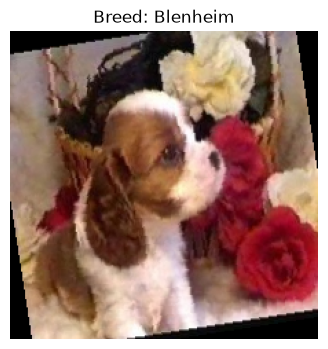

In [11]:
def unnormalize(tensor_image, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverses normalization so the image displays correctly."""
    img = tensor_image.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.permute(1, 2, 0).numpy().clip(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(unnormalize(images_batch[0]))
plt.title(f"Breed: {train_dataset.classes[labels_batch[0]]}")
plt.axis("off")
plt.show()

## 8. Summary

What this notebook builds:

- Loads the cleaned dataset directly from `dogs_updated.csv` (Cameron's verified/cleaned images)
- Builds a `torchvision.transforms` pipeline: resize, normalize using ImageNet stats, and
  augmentation (flip + rotation) applied to training images only
- A custom `DogBreedDataset` class that reads from the dataframe and loads one image at a time
- A shared `class_to_idx` mapping so breed labels stay consistent across train/valid/test
- `DataLoader` objects for train, valid, and test, ready to be handed to whoever builds the
  model training loop
